In [13]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from matplotlib import pyplot as plt
import seaborn as sns
import sys
sys.path.append("../")
from scripts.preprocessing import preprocess_text, extract_sentiment
from scripts.preprocessing import setup_nltk


Load Dataset

In [8]:
# Load the dataset
df = pd.read_csv("../data/raw_analyst_ratings.csv")
df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


Descriptive Statistics

In [ ]:
# Descriptive Statistics
df["headline_length"] = df["headline"].astype(str).str.len()
print(df["headline_length"].describe())

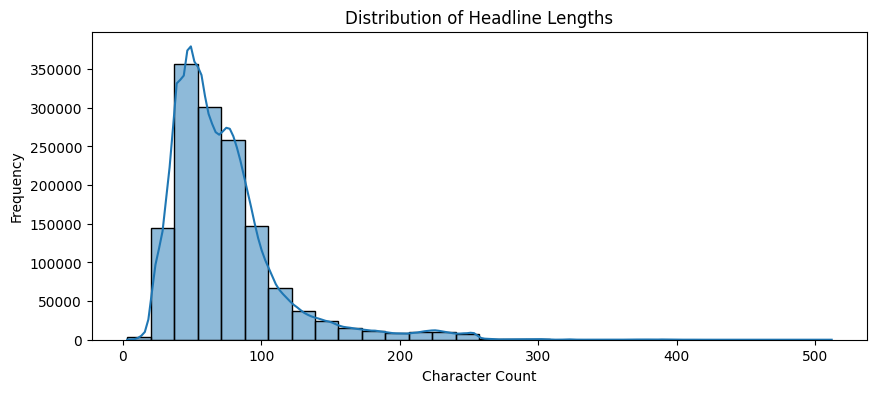

In [12]:
# Plot
plt.figure(figsize=(10, 4))
sns.histplot(df["headline_length"], bins=30, kde=True)
plt.title("Distribution of Headline Lengths")
plt.xlabel("Character Count")
plt.ylabel("Frequency")
plt.show()


In [10]:
# Articles Per Publisher
top_publishers = df["publisher"].value_counts().head(10)
print(top_publishers)

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64


In [ ]:
# Convert 'date' column to datetime objects
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df.dropna(subset=['date'], inplace=True)


--- Publication Date Analysis ---

Articles per Day of Week:
publication_day_of_week
Monday       10322
Tuesday      11002
Wednesday    11891
Thursday     12688
Friday        9381
Saturday       267
Sunday         436
Name: count, dtype: int64


C:\Users\Teddy\AppData\Local\Temp\ipykernel_3692\894925130.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=articles_per_day.index, y=articles_per_day.values, palette='plasma')


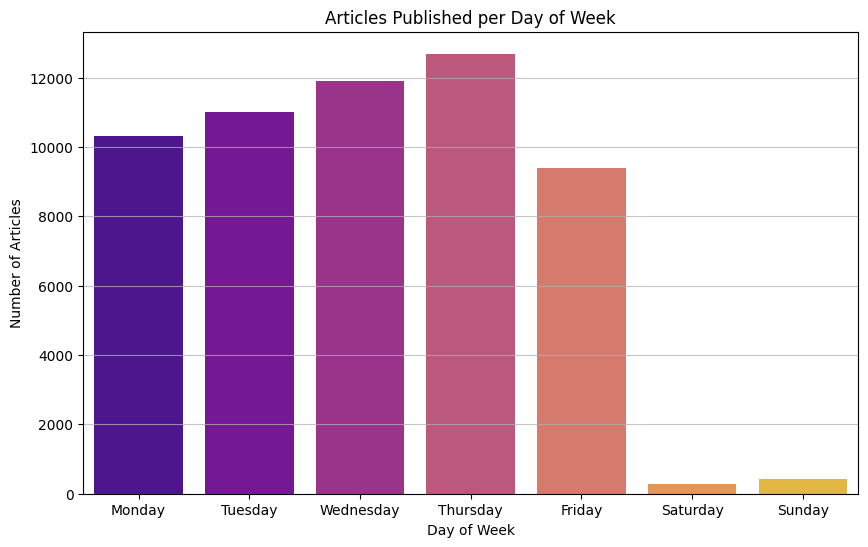

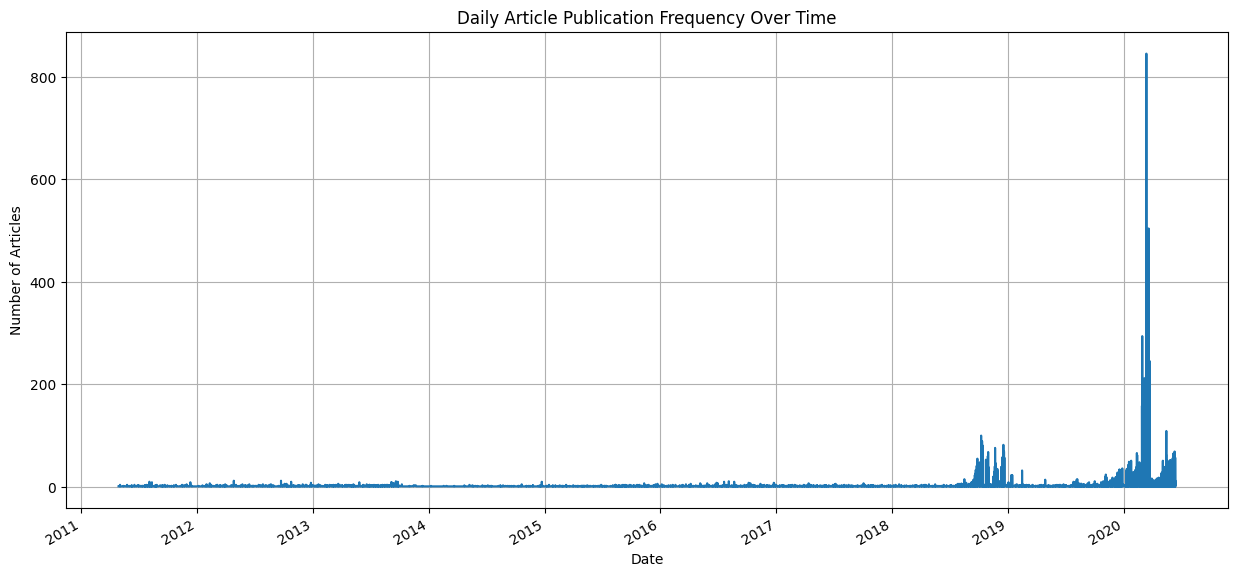

C:\Users\Teddy\AppData\Local\Temp\ipykernel_3692\894925130.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=articles_per_hour.index, y=articles_per_hour.values, palette='magma')


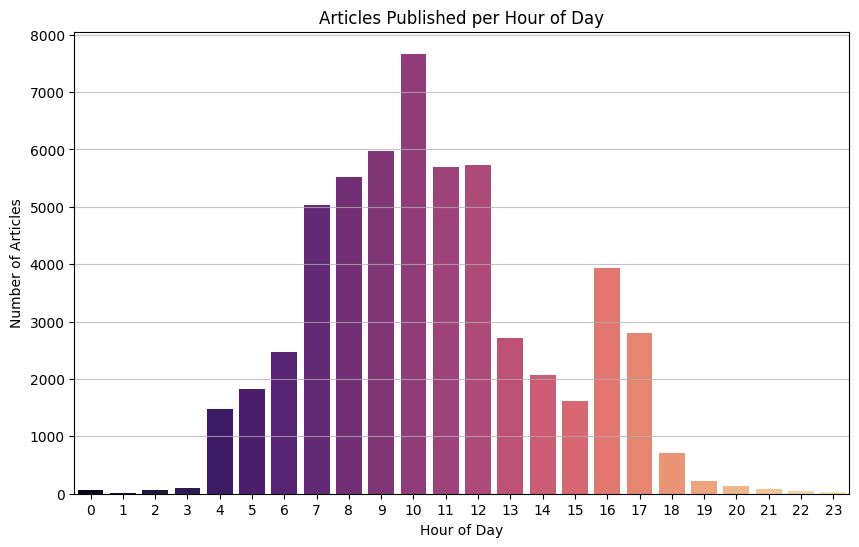

In [9]:
print("\n--- Publication Date Analysis ---")
df['publication_day_of_week'] = df['date'].dt.day_name()
df['publication_hour'] = df['date'].dt.hour
df['publication_month'] = df['date'].dt.month_name()
df['publication_year'] = df['date'].dt.year

# Articles per day of week
articles_per_day = df['publication_day_of_week'].value_counts().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
])
print("\nArticles per Day of Week:")
print(articles_per_day)

plt.figure(figsize=(10, 6))
sns.barplot(x=articles_per_day.index, y=articles_per_day.values, palette='plasma')
plt.title('Articles Published per Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Articles')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Articles over time (daily frequency)
articles_daily_count = df['date'].value_counts().sort_index()

plt.figure(figsize=(15, 7))
articles_daily_count.plot(kind='line')
plt.title('Daily Article Publication Frequency Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.grid(True)
plt.show()

# Articles per hour of day
articles_per_hour = df['publication_hour'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=articles_per_hour.index, y=articles_per_hour.values, palette='magma')
plt.title('Articles Published per Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Articles')
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.75)
plt.show()

<Axes: title={'center': 'Top 10 Most Active Publishers'}, xlabel='publisher'>

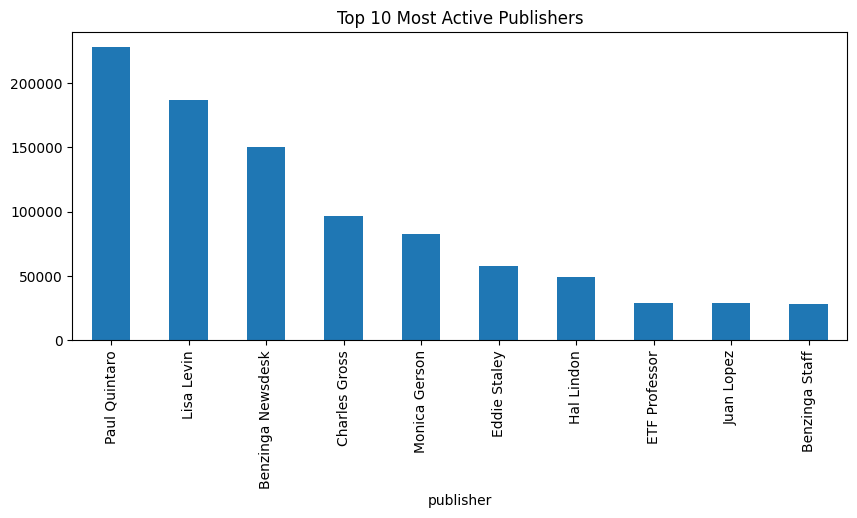

In [ ]:
# Top 10 Publishers Bar Plot

top_publishers.plot(kind="bar", figsize=(10, 4), title="Top 10 Most Active Publishers")

Articles per publisher


--- Publication Date Analysis ---

Articles per Day of Week:
publication_day_of_week
Monday       10322
Tuesday      11002
Wednesday    11891
Thursday     12688
Friday        9381
Saturday       267
Sunday         436
Name: count, dtype: int64


C:\Users\Teddy\AppData\Local\Temp\ipykernel_3692\894925130.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=articles_per_day.index, y=articles_per_day.values, palette='plasma')


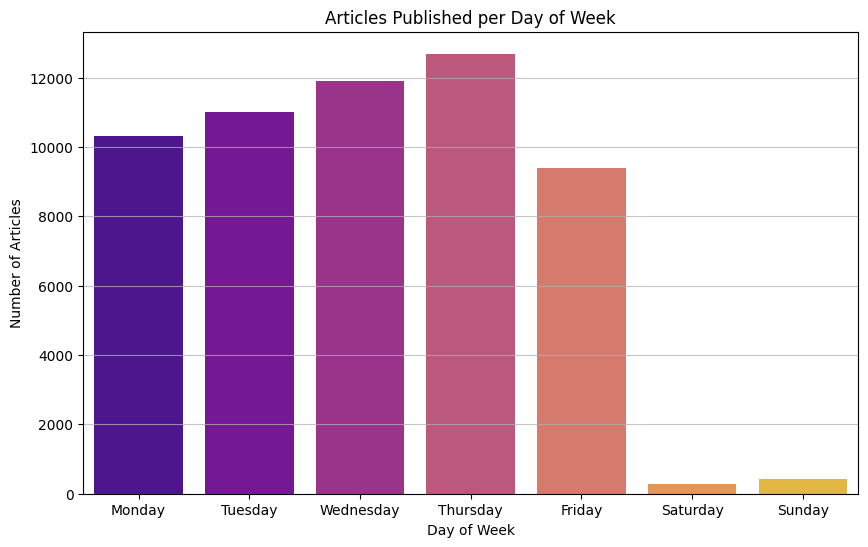

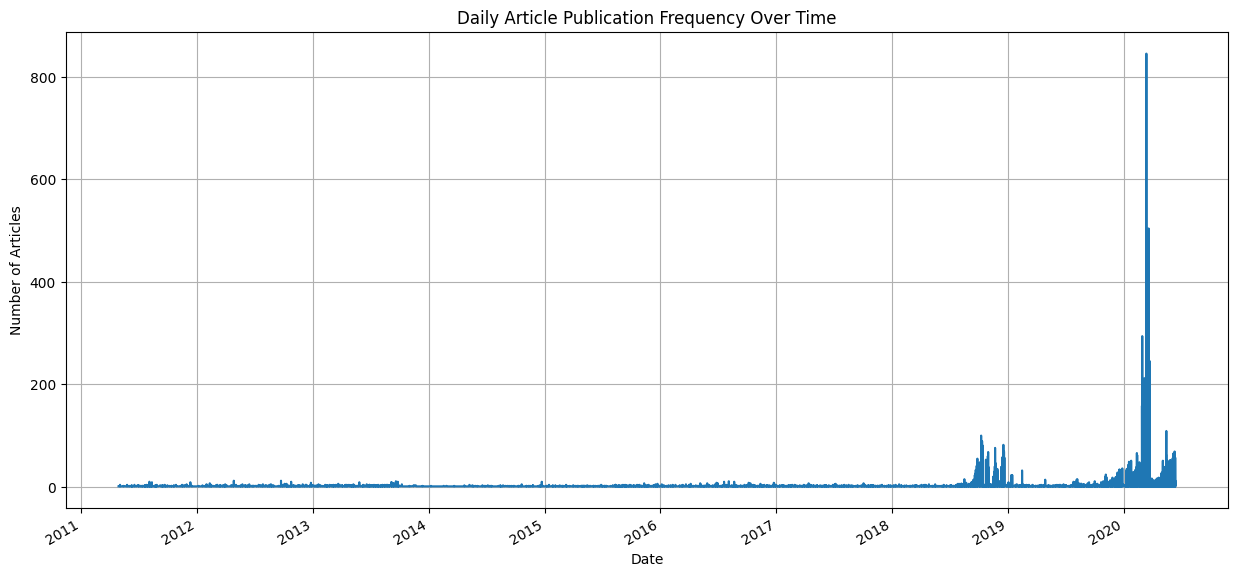

C:\Users\Teddy\AppData\Local\Temp\ipykernel_3692\894925130.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=articles_per_hour.index, y=articles_per_hour.values, palette='magma')


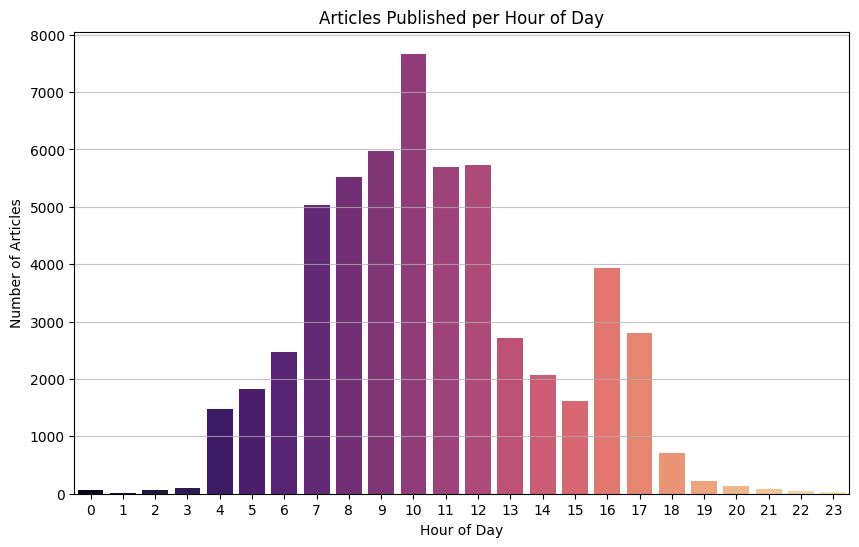

In [10]:
print("\n--- Publication Date Analysis ---")
df['publication_day_of_week'] = df['date'].dt.day_name()
df['publication_hour'] = df['date'].dt.hour
df['publication_month'] = df['date'].dt.month_name()
df['publication_year'] = df['date'].dt.year

# Articles per day of week
articles_per_day = df['publication_day_of_week'].value_counts().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
])
print("\nArticles per Day of Week:")
print(articles_per_day)

plt.figure(figsize=(10, 6))
sns.barplot(x=articles_per_day.index, y=articles_per_day.values, palette='plasma')
plt.title('Articles Published per Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Articles')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Articles over time (daily frequency)
articles_daily_count = df['date'].value_counts().sort_index()

plt.figure(figsize=(15, 7))
articles_daily_count.plot(kind='line')
plt.title('Daily Article Publication Frequency Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.grid(True)
plt.show()

# Articles per hour of day
articles_per_hour = df['publication_hour'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=articles_per_hour.index, y=articles_per_hour.values, palette='magma')
plt.title('Articles Published per Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Articles')
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.75)
plt.show()

Apply text cleaning

In [11]:


setup_nltk()


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Teddy\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Teddy\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Teddy\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
